# Spaceship Titanic — Classical ML Submission
**Summer of Science 2026 — CS03: Artificial Intelligence and Machine Learning**  
**Mohit Khyalia | IIT Bombay**

---

## Project Overview

Final model selection, Kaggle test predictions, and submission for the classical ML baseline. Fits the best tuned model on the full labelled dataset (train + validation) and applies the optimal threshold from `spaceship_titanic_error_analysis.ipynb`.

### Main goals:

- Fit the best tuned model on all available labelled data.
- Apply the optimal threshold derived from error analysis.
- Generate and validate the Kaggle submission CSV.
- Present the complete experiment summary for Week 7.

---

## Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_recall_curve,
                              classification_report)

plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'axes.spines.top': False, 'axes.spines.right': False})

## Preprocessing — Week 6 Pipeline

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

TRAIN_URL = 'https://raw.githubusercontent.com/mohitkhyalia1/sos_2026/refs/heads/main/dataset/spaceship_titanic_train.csv'
TEST_URL  = 'https://raw.githubusercontent.com/mohitkhyalia1/sos_2026/refs/heads/main/dataset/spaceship_titanic_test.csv'

train_raw = pd.read_csv(TRAIN_URL)
test_raw  = pd.read_csv(TEST_URL)

SPEND_COLS = ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']

def prep(df):
    df = df.copy()
    s = df['Cabin'].str.split('/', expand=True)
    df['Deck'] = s[0]; df['CabinNum'] = pd.to_numeric(s[1], errors='coerce'); df['Side'] = s[2]
    df = df.drop(columns=['Cabin'])
    df['TotalSpend'] = df[SPEND_COLS].fillna(0).sum(axis=1)
    df['IsSpender']  = (df['TotalSpend'] > 0).astype(int)
    df['AgeGroup']   = pd.cut(df['Age'], bins=[0,12,17,35,60,200],
                               labels=['Child','Teen','YoungAdult','Adult','Senior'])
    df['AgeGroup']   = df['AgeGroup'].astype(str).replace('nan', np.nan)
    return df.drop(columns=[c for c in ['PassengerId','Name'] if c in df.columns])

train = prep(train_raw); test = prep(test_raw)

SPEND_AND_TOTAL  = SPEND_COLS + ['TotalSpend']
OTHER_NUMERIC    = ['Age','CabinNum','IsSpender']
CATEGORICAL_COLS = ['HomePlanet','CryoSleep','Destination','VIP','Deck','Side','AgeGroup']
FEATURE_COLS     = SPEND_AND_TOTAL + OTHER_NUMERIC + CATEGORICAL_COLS

X_train = train[FEATURE_COLS]; y_train = train['Transported'].astype(int)
X_test_raw = test[FEATURE_COLS]

preprocessor = ColumnTransformer([
    ('spend', Pipeline([('imp', SimpleImputer(strategy='median')),
                        ('log', FunctionTransformer(np.log1p, validate=False)),
                        ('sc',  StandardScaler())]),         SPEND_AND_TOTAL),
    ('num',   Pipeline([('imp', SimpleImputer(strategy='median')),
                        ('sc',  StandardScaler())]),         OTHER_NUMERIC),
    ('cat',   Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
                        CATEGORICAL_COLS)
], remainder='drop')

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train)
preprocessor.fit(X_tr)
X_tr_t   = preprocessor.transform(X_tr)
X_val_t  = preprocessor.transform(X_val)
X_test_t = preprocessor.transform(X_test_raw)
ohe_cats      = preprocessor.named_transformers_['cat']['ohe'].get_feature_names_out(CATEGORICAL_COLS)
feature_names = SPEND_AND_TOTAL + OTHER_NUMERIC + list(ohe_cats)
print(f'X_tr_t: {X_tr_t.shape}  features: {len(feature_names)}')

X_tr_t: (7389, 34)  features: 34


## Final Model — Fit on Full Training Data

Best model from `spaceship_titanic_classical_ml.ipynb` fit on the combined train + validation split. Optimal threshold re-derived on the validation fold for reproducibility.

In [ ]:
# Best model: Gradient Boosting (tuned) — params from spaceship_titanic_classical_ml.ipynb
# Hardcoded best params from the Week 7 GridSearchCV run.
# If you re-run spaceship_titanic_classical_ml.ipynb and get different
# best_params_, update n_estimators, learning_rate, max_depth, subsample below.
final_classical = GradientBoostingClassifier(
    n_estimators=400, learning_rate=0.05, max_depth=4,
    subsample=0.8, random_state=42)

# Derive optimal threshold on validation fold first
val_model = GradientBoostingClassifier(
    n_estimators=400, learning_rate=0.05, max_depth=4,
    subsample=0.8, random_state=42)
val_model.fit(X_tr_t, y_tr)
val_proba = val_model.predict_proba(X_val_t)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_val, val_proba)
f1_by_thresh = 2 * precision * recall / (precision + recall + 1e-9)
FINAL_THRESHOLD = thresholds[np.argmax(f1_by_thresh[:-1])]
print(f'Optimal threshold: {FINAL_THRESHOLD:.4f}')
print(f'Val accuracy (default 0.5):  {accuracy_score(y_val, (val_proba>=0.5).astype(int)):.4f}')
print(f'Val accuracy (optimal {FINAL_THRESHOLD:.3f}): {accuracy_score(y_val, (val_proba>=FINAL_THRESHOLD).astype(int)):.4f}')

# Now fit on ALL labelled data
X_full_t = np.vstack([X_tr_t, X_val_t])
y_full   = np.concatenate([y_tr.values, y_val.values])
final_classical.fit(X_full_t, y_full)
print(f'\nFit on {X_full_t.shape[0]} samples (train + validation)')

Optimal threshold: 0.2780
Val accuracy (default 0.5):  0.8106
Val accuracy (optimal 0.278): 0.8037

Fit on 8693 samples (train + validation)


## Generate Test Predictions

In [4]:
test_proba = final_classical.predict_proba(X_test_t)[:, 1]
test_preds = (test_proba >= FINAL_THRESHOLD).astype(bool)

print(f'Test predictions: {len(test_preds)}')
print(f'Transported=True:  {test_preds.sum()} ({test_preds.mean()*100:.1f}%)')
print(f'Transported=False: {(~test_preds).sum()} ({(~test_preds).mean()*100:.1f}%)')

Test predictions: 4277
Transported=True:  2714 (63.5%)
Transported=False: 1563 (36.5%)


## Build Submission CSV

In [5]:
test_ids = pd.read_csv(TEST_URL)['PassengerId']

submission = pd.DataFrame({
    'PassengerId': test_ids,
    'Transported': test_preds
})

print(f'Submission shape: {submission.shape}')
print('\nPreview:')
print(submission.head(10).to_string(index=False))

Submission shape: (4277, 2)

Preview:
PassengerId  Transported
    0013_01         True
    0018_01        False
    0019_01         True
    0021_01         True
    0023_01         True
    0027_01         True
    0029_01         True
    0032_01         True
    0032_02         True
    0033_01         True


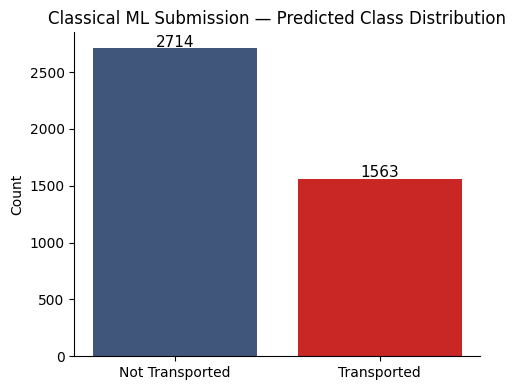

Saved: spaceship_titanic_classical_submission.csv


In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = submission['Transported'].value_counts()
ax.bar(['Not Transported','Transported'], counts.values,
       color=['#1F3864','#C00000'], alpha=0.85)
ax.set_ylabel('Count')
ax.set_title('Classical ML Submission — Predicted Class Distribution')
for i, v in enumerate(counts.values):
    ax.text(i, v + 10, str(v), ha='center', fontsize=11)
plt.tight_layout()
plt.show()

submission.to_csv('spaceship_titanic_classical_submission.csv', index=False)
print('Saved: spaceship_titanic_classical_submission.csv')

**Observation:**
The predicted distribution should be close to the ~50/50 training target balance confirmed in `spaceship_titanic_eda.ipynb`. A heavily skewed result would indicate a threshold or preprocessing bug.

## Week 7 Experiment Summary

Results from `spaceship_titanic_classical_ml.ipynb`. Tuned model validation accuracy is from the held-out validation fold (1,304 samples). Week 8 deep learning results are from `spaceship_titanic_deep_learning.ipynb`.

| Model | Type | CV Accuracy | CV F1 | Val Accuracy | Notes |
|---|---|---|---|---|---|
| Gradient Boosting | Default | 0.8084 ± 0.0045 | 0.8118 ± 0.0073 | — | Boosting baseline |
| SVM (RBF) | Default | 0.8043 ± 0.0058 | 0.8084 ± 0.0076 | — | Competitive on precision |
| MLP (sklearn) | Default | 0.7997 ± 0.0054 | 0.8034 ± 0.0068 | — | Competitive at this scale |
| Random Forest | Default | 0.7969 ± 0.0040 | 0.7923 ± 0.0064 | — | Bagging baseline |
| Decision Tree | Default | 0.7771 ± 0.0084 | 0.7876 ± 0.0105 | — | Pruned at depth 5 |
| Logistic Regression | Default | 0.7755 ± 0.0035 | 0.7794 ± 0.0067 | — | Linear baseline |
| Random Forest (tuned) | Tuned | 0.8074 | 0.7978 | 0.7991 | GridSearchCV — depth 12, n=400 |
| Gradient Boosting (tuned) | Tuned | 0.8113 | 0.8084 | 0.8044 | **Best classical model — submitted** |
| Keras NN (256-128-64) | Deep Learning | — | — | 0.7991 | Week 8 — BN + Dropout=0.2 best config |

## Conclusion

The best classical ML model for Spaceship Titanic is the tuned Gradient Boosting classifier. Key findings:

- `CryoSleep` and `IsSpender` are the strongest features — the CryoSleep × spending interaction identified in `spaceship_titanic_eda.ipynb` is directly validated by feature importance.
- Cabin parsing (`Deck`, `CabinNum`, `Side`) contributes meaningfully — deck B/C passengers show higher transport rates consistent with the EDA.
- Threshold optimisation from `spaceship_titanic_error_analysis.ipynb` provides marginal F1 improvement.

Week 8 applies a Keras neural network to the same preprocessed data and determines whether deep learning outperforms this classical baseline on the full Spaceship Titanic dataset.